In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [21]:
from package_files.benefits_defns import *

In [20]:
import importlib
import package_files.benefits_defns
importlib.reload(package_files.benefits_defns)


<module 'package_files.benefits_defns' from '/data/sant6443/SkillScale/package_files/benefits_defns.py'>

In [5]:
usdf_salary = pd.read_parquet('../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip')

In [24]:
usdf_salary = usdf_salary[usdf_salary['SALARY'].notnull()]

In [12]:
usdf_salary.columns

Index(['ID', 'CITY_NAME', 'COUNTY_NAME', 'STATE_NAME', 'NAICS_2022_2',
       'NAICS_2022_2_NAME', 'MIN_EDULEVELS_NAME', 'EMPLOYMENT_TYPE',
       'EMPLOYMENT_TYPE_NAME', 'IS_INTERNSHIP', 'REMOTE_TYPE',
       'REMOTE_TYPE_NAME', 'SKILLS', 'SKILLS_NAME', 'POSTED',
       'LAST_UPDATED_DATE', 'ONET', 'ONET_NAME', 'ONET_2019', 'ONET_2019_NAME',
       'SOC_2021_2_NAME', 'SOC_2021_2', 'MIN_YEARS_EXPERIENCE', 'COMPANY',
       'COMPANY_NAME', 'COMPANY_RAW', 'SALARY', 'EXPIRED', 'DURATION',
       'AI ROLE', 'wfh_wham_prob', 'wfh_wham', 'YEAR', 'EDU_ASSISTANCE',
       'PAID_LEAVE', 'WELLBEING', 'HEALTH_WELLBEING', 'PARENTAL_LEAVE',
       'CULTURE', 'REMOTE_KW'],
      dtype='object')

In [8]:
def median_ci(data, confidence=0.95):
    data = np.array(data)
    n = len(data)
    median = np.median(data)
    z = stats.norm.ppf(0.5 + confidence / 2.0)
    margin_of_error = z * np.std(data, ddof=1) / np.sqrt(n)
    return median, median - margin_of_error, median + margin_of_error

[<matplotlib.lines.Line2D object at 0x7f39bb6728d0>, <matplotlib.lines.Line2D object at 0x7f39bb671640>, <matplotlib.lines.Line2D object at 0x7f39bb673530>, <matplotlib.lines.Line2D object at 0x7f39bb671a30>, <matplotlib.lines.Line2D object at 0x7f39bb6725a0>, <matplotlib.lines.Line2D object at 0x7f39bb673e90>] ['AI ROLE', 'False', 'True', 'EDU_ASSISTANCE', 'False', 'True']


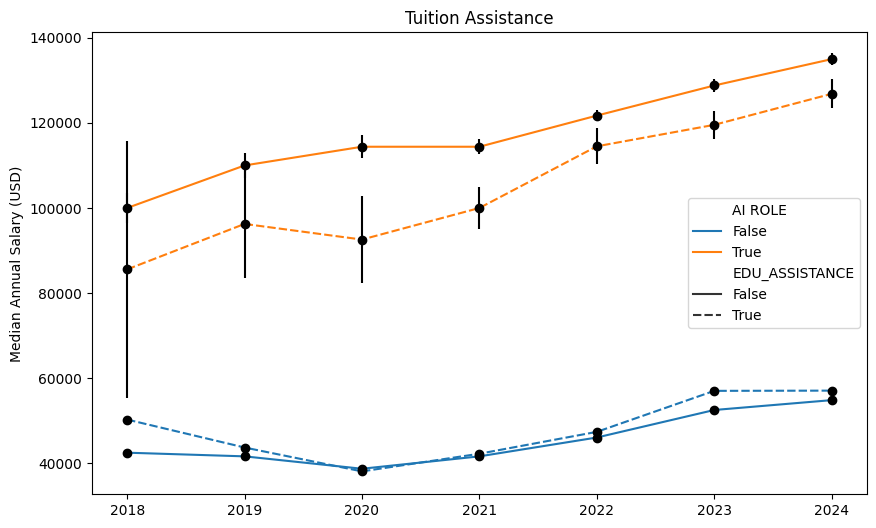

[<matplotlib.lines.Line2D object at 0x7f39bbcf2c30>, <matplotlib.lines.Line2D object at 0x7f39bbcf1d00>, <matplotlib.lines.Line2D object at 0x7f39bbcf1700>, <matplotlib.lines.Line2D object at 0x7f39bbb909b0>, <matplotlib.lines.Line2D object at 0x7f39bbb90380>, <matplotlib.lines.Line2D object at 0x7f39bbcf1490>] ['AI ROLE', 'False', 'True', 'PAID_LEAVE', 'False', 'True']


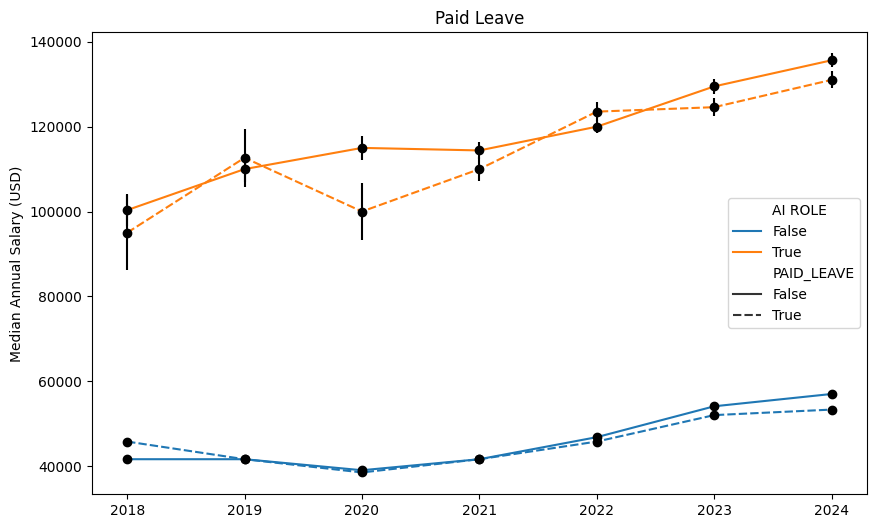

[<matplotlib.lines.Line2D object at 0x7f3bcbc53ec0>, <matplotlib.lines.Line2D object at 0x7f3bcbc526f0>, <matplotlib.lines.Line2D object at 0x7f3bcbc50d10>, <matplotlib.lines.Line2D object at 0x7f3bcbce8770>, <matplotlib.lines.Line2D object at 0x7f3bcbcea690>, <matplotlib.lines.Line2D object at 0x7f3bcbceb8f0>] ['AI ROLE', 'False', 'True', 'HEALTH_WELLBEING', 'False', 'True']


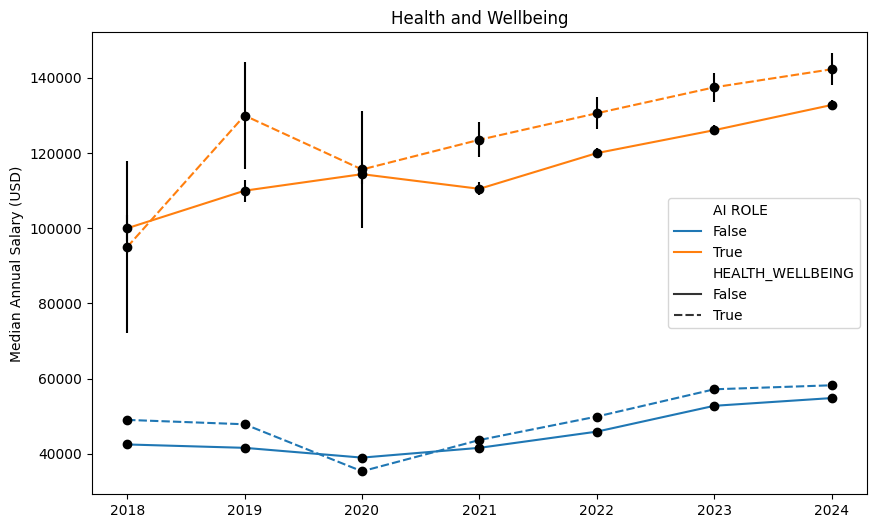

[<matplotlib.lines.Line2D object at 0x7f3bcc184980>, <matplotlib.lines.Line2D object at 0x7f3bcc184470>, <matplotlib.lines.Line2D object at 0x7f3bcc184110>, <matplotlib.lines.Line2D object at 0x7f3bcc1862a0>, <matplotlib.lines.Line2D object at 0x7f3bcc184f50>, <matplotlib.lines.Line2D object at 0x7f3bcc010740>] ['AI ROLE', 'False', 'True', 'PARENTAL_LEAVE', 'False', 'True']


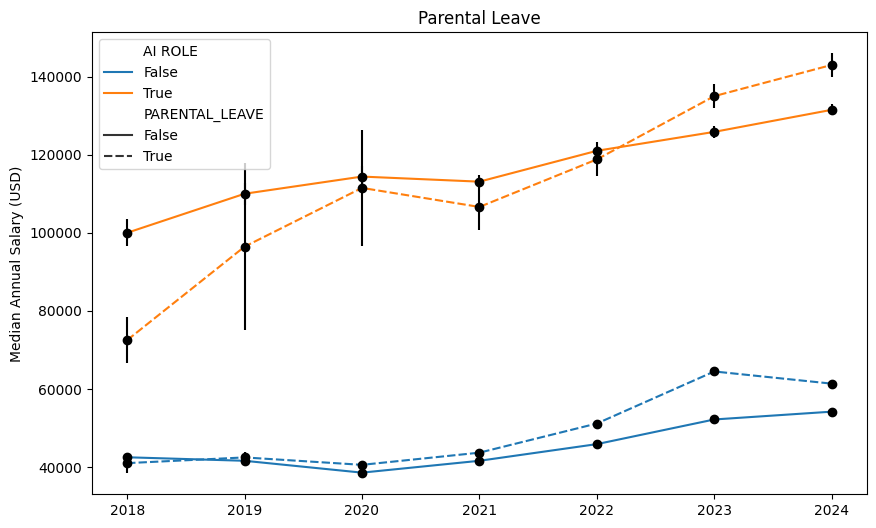

[<matplotlib.lines.Line2D object at 0x7f3bcc7f4b60>, <matplotlib.lines.Line2D object at 0x7f3bcc7f4530>, <matplotlib.lines.Line2D object at 0x7f3bcc784440>, <matplotlib.lines.Line2D object at 0x7f3bcc7f6540>, <matplotlib.lines.Line2D object at 0x7f3bcc7f6780>, <matplotlib.lines.Line2D object at 0x7f3bcc7f6d80>] ['AI ROLE', 'False', 'True', 'CULTURE', 'False', 'True']


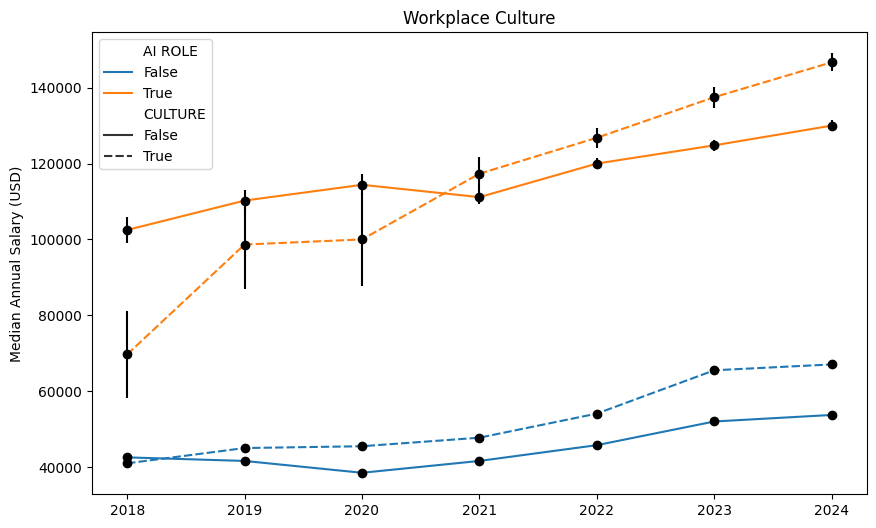

[<matplotlib.lines.Line2D object at 0x7f43db19c6e0>, <matplotlib.lines.Line2D object at 0x7f43db19d8b0>, <matplotlib.lines.Line2D object at 0x7f43db19e0f0>, <matplotlib.lines.Line2D object at 0x7f3bccc42780>, <matplotlib.lines.Line2D object at 0x7f3bccc41580>, <matplotlib.lines.Line2D object at 0x7f3bcccbd310>] ['AI ROLE', 'False', 'True', 'wfh_wham', '0.0', '1.0']


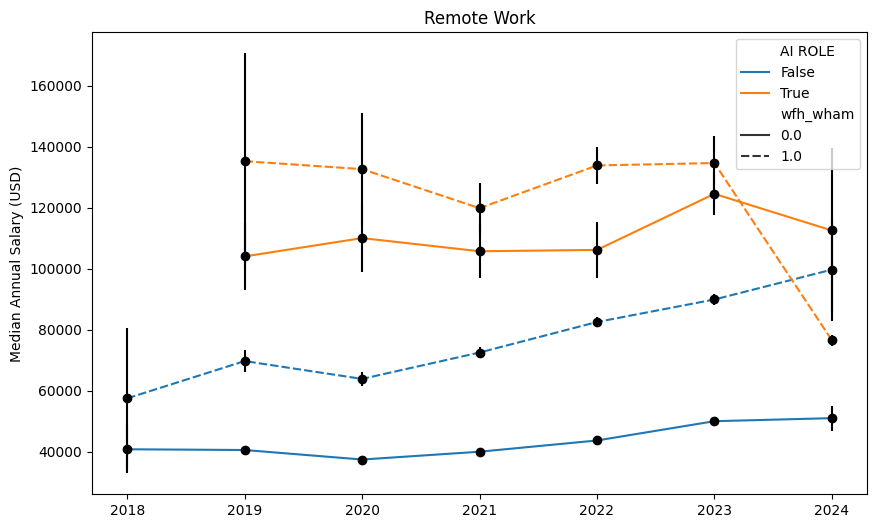

[<matplotlib.lines.Line2D object at 0x7f3990225670>, <matplotlib.lines.Line2D object at 0x7f3990225070>, <matplotlib.lines.Line2D object at 0x7f3990224ce0>, <matplotlib.lines.Line2D object at 0x7f3990224800>, <matplotlib.lines.Line2D object at 0x7f39902243b0>, <matplotlib.lines.Line2D object at 0x7f399039b560>] ['AI ROLE', 'False', 'True', 'REMOTE_KW', 'False', 'True']


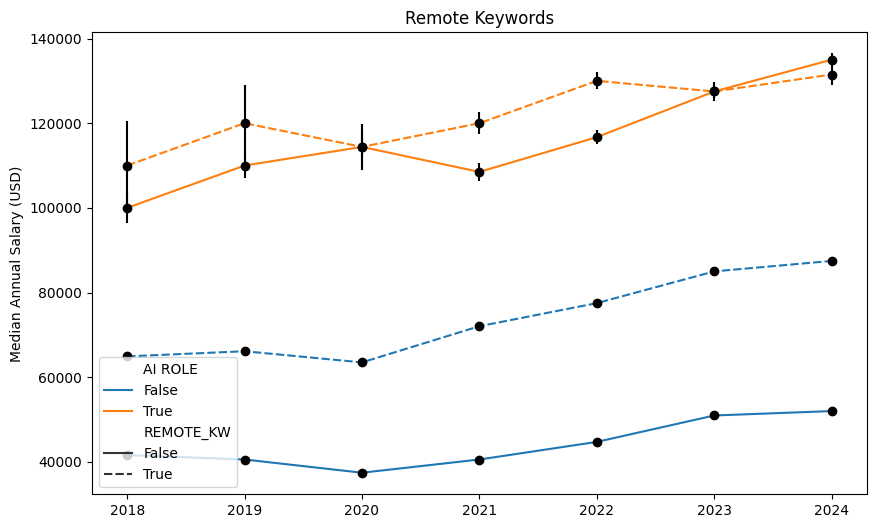

In [26]:
for benefit in benefits4:
    grouped_salary = usdf_salary.groupby(['YEAR', 'AI ROLE', benefit])['SALARY'].apply(
        lambda x: pd.Series(median_ci(x, confidence=0.95), index=['Median', 'CI_Lower', 'CI_Upper'])
    ).reset_index()
    # Convert the 'AI ROLE' and benefit to categorical if they are not already
    grouped_salary['AI ROLE'] = grouped_salary['AI ROLE'].astype(str)
    grouped_salary['SALARY'] = pd.to_numeric(grouped_salary['SALARY'], errors='coerce')
    grouped_salary['YEAR'] = grouped_salary['YEAR'].astype(int)

    grouped_salary[benefit] = grouped_salary[benefit].astype(str)

    median_data = grouped_salary[grouped_salary['level_3'] == 'Median']

    # Plotting
    plt.figure(figsize=(10, 6))

    # Use Seaborn's lineplot to plot the median salaries
    sns.lineplot(
        data=median_data,
        x='YEAR',
        y='SALARY',
        hue='AI ROLE',
        style=benefit,
        markers=False,
        errorbar=None
    )

    # Adding error bars manually
    for skill in median_data['AI ROLE'].unique():
        for remote in grouped_salary[benefit].unique():
            subset = grouped_salary[(grouped_salary['AI ROLE'] == skill) & (grouped_salary[benefit] == remote)]
            medians = subset[subset['level_3'] == 'Median']
            ci_lowers = subset[subset['level_3'] == 'CI_Lower']['SALARY'].astype(float).values
            ci_uppers = subset[subset['level_3'] == 'CI_Upper']['SALARY'].astype(float).values
            yerr = np.array([medians['SALARY'].values - ci_lowers, ci_uppers - medians['SALARY'].values])

            plt.errorbar(
                x=medians['YEAR'],
                y=medians['SALARY'],
                yerr=yerr,
                fmt='o',
                color='black'
            )

    plt.xticks(median_data['YEAR'].unique())
    # Customize the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    print(handles, labels)
    # Extract the relevant handles and labels
    new_handles = handles
    new_labels = ['AI Skills','No', 'Yes', f'{benefits_labels_map[benefit]}','No', 'Yes']
    plt.legend(handles=new_handles, labels=new_labels, loc = 'upper left')
    # set legend location
    # plt.legend(['','No AI Skills','AI Skills','','Not Remote','Remote'])
    # plt.legend(handles=handles[:4], labels=new_labels, title='Job Type and Remote Work')
    plt.xlabel(None)
    plt.ylabel('Median Annual Salary (USD)')
    plt.title(benefits_labels_map[benefit])
    # plt.title('Median Annual Salary by AI Skills and Remote Work with 95% Confidence Intervals')
    
    # if salary folder doesn't exist, create it
    if not os.path.exists('../figures/salary'):
        os.makedirs('../figures/salary')
    plt.savefig(f'../figures/salary/salary_by_{benefit}.png')

    plt.show()

# Updated Colors

   YEAR AI ROLE EDU_ASSISTANCE   level_3        SALARY
0  2018   False          False    Median  42463.000000
1  2018   False          False  CI_Lower  42295.789834
2  2018   False          False  CI_Upper  42630.210166
3  2018   False           True    Median  50252.000000
4  2018   False           True  CI_Lower  49629.437523
    YEAR AI ROLE EDU_ASSISTANCE level_3    SALARY
0   2018   False          False  Median   42463.0
3   2018   False           True  Median   50252.0
6   2018    True          False  Median  100000.0
9   2018    True           True  Median   85561.0
12  2019   False          False  Median   41600.0
[<matplotlib.lines.Line2D object at 0x7f39ba5b1910>, <matplotlib.lines.Line2D object at 0x7f39b9d53530>, <matplotlib.lines.Line2D object at 0x7f39ba5b0fb0>, <matplotlib.lines.Line2D object at 0x7f39ba5b2e10>, <matplotlib.lines.Line2D object at 0x7f39b9d52960>, <matplotlib.lines.Line2D object at 0x7f39b9d50a10>] ['AI ROLE', 'True', 'False', 'EDU_ASSISTANCE', 'True', 'F

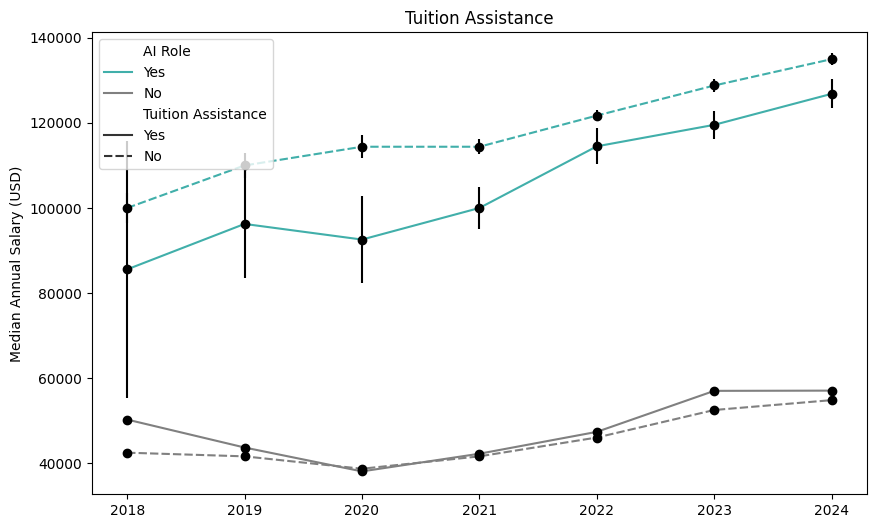

   YEAR AI ROLE PAID_LEAVE   level_3        SALARY
0  2018   False      False    Median  41600.000000
1  2018   False      False  CI_Lower  41419.431091
2  2018   False      False  CI_Upper  41780.568909
3  2018   False       True    Median  45760.000000
4  2018   False       True  CI_Lower  45389.902444
    YEAR AI ROLE PAID_LEAVE level_3    SALARY
0   2018   False      False  Median   41600.0
3   2018   False       True  Median   45760.0
6   2018    True      False  Median  100328.0
9   2018    True       True  Median   95000.0
12  2019   False      False  Median   41600.0
[<matplotlib.lines.Line2D object at 0x7f39b8d617c0>, <matplotlib.lines.Line2D object at 0x7f3847dfb530>, <matplotlib.lines.Line2D object at 0x7f39b89d0a40>, <matplotlib.lines.Line2D object at 0x7f39b89d2750>, <matplotlib.lines.Line2D object at 0x7f39b8d61280>, <matplotlib.lines.Line2D object at 0x7f39b8d60620>] ['AI ROLE', 'True', 'False', 'PAID_LEAVE', 'True', 'False']


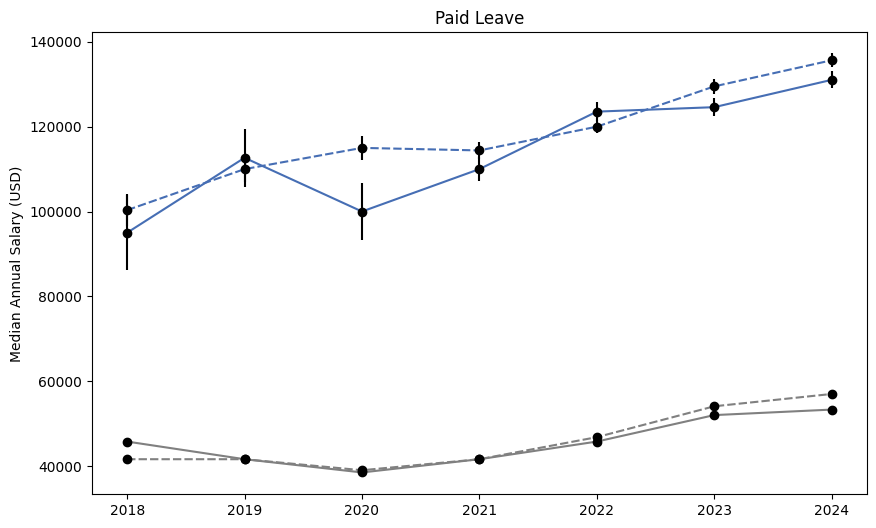

   YEAR AI ROLE HEALTH_WELLBEING   level_3        SALARY
0  2018   False            False    Median  42500.000000
1  2018   False            False  CI_Lower  42334.699843
2  2018   False            False  CI_Upper  42665.300157
3  2018   False             True    Median  49033.500000
4  2018   False             True  CI_Lower  48150.679721
    YEAR AI ROLE HEALTH_WELLBEING level_3    SALARY
0   2018   False            False  Median   42500.0
3   2018   False             True  Median   49033.5
6   2018    True            False  Median  100000.0
9   2018    True             True  Median   95000.0
12  2019   False            False  Median   41600.0
[<matplotlib.lines.Line2D object at 0x7f3847ec3770>, <matplotlib.lines.Line2D object at 0x7f3847ec18b0>, <matplotlib.lines.Line2D object at 0x7f3847ec1520>, <matplotlib.lines.Line2D object at 0x7f3847ec17f0>, <matplotlib.lines.Line2D object at 0x7f3bc5794b30>, <matplotlib.lines.Line2D object at 0x7f3847ec34a0>] ['AI ROLE', 'True', 'False', 'HEA

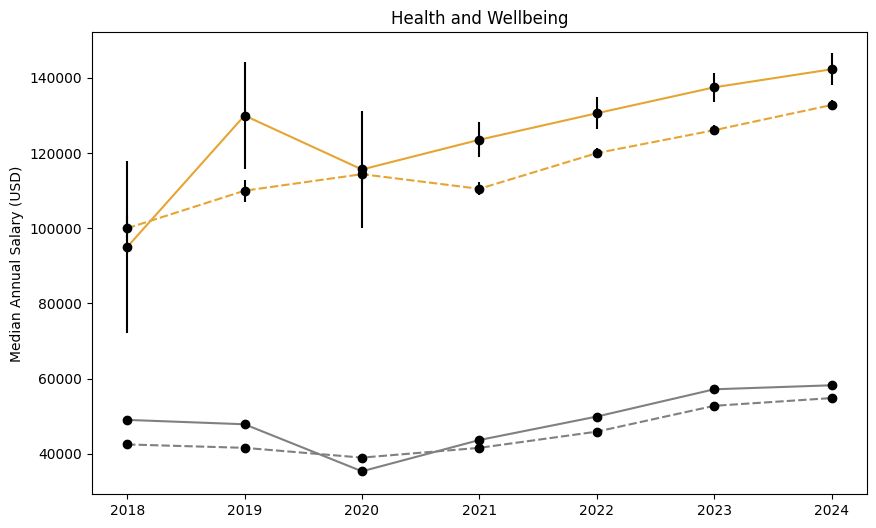

   YEAR AI ROLE PARENTAL_LEAVE   level_3        SALARY
0  2018   False          False    Median  42500.000000
1  2018   False          False  CI_Lower  42337.140667
2  2018   False          False  CI_Upper  42662.859333
3  2018   False           True    Median  41000.000000
4  2018   False           True  CI_Lower  38399.898625
    YEAR AI ROLE PARENTAL_LEAVE level_3    SALARY
0   2018   False          False  Median   42500.0
3   2018   False           True  Median   41000.0
6   2018    True          False  Median  100000.0
9   2018    True           True  Median   72500.0
12  2019   False          False  Median   41600.0
[<matplotlib.lines.Line2D object at 0x7f39b9509580>, <matplotlib.lines.Line2D object at 0x7f39b95092e0>, <matplotlib.lines.Line2D object at 0x7f39926a7890>, <matplotlib.lines.Line2D object at 0x7f39b9973380>, <matplotlib.lines.Line2D object at 0x7f39b99701d0>, <matplotlib.lines.Line2D object at 0x7f39b9970fb0>] ['AI ROLE', 'True', 'False', 'PARENTAL_LEAVE', 'True', 'F

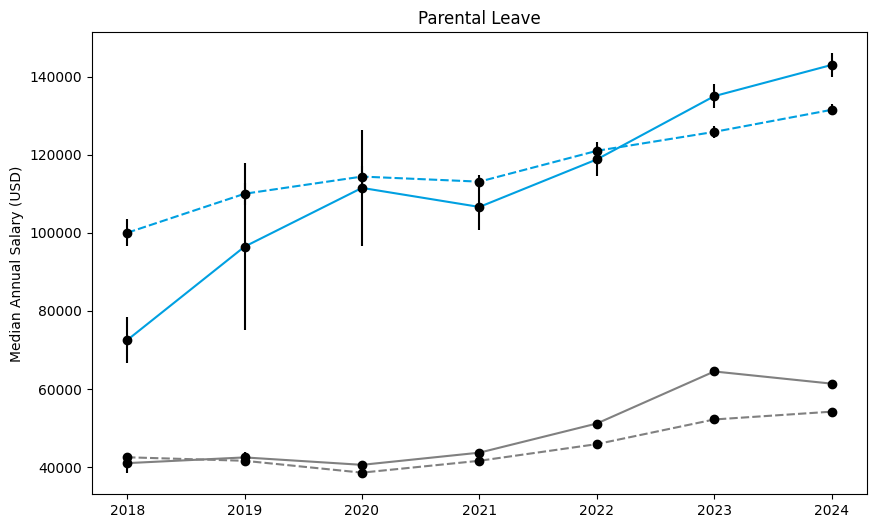

   YEAR AI ROLE CULTURE   level_3        SALARY
0  2018   False   False    Median  42540.000000
1  2018   False   False  CI_Lower  42375.166167
2  2018   False   False  CI_Upper  42704.833833
3  2018   False    True    Median  40974.000000
4  2018   False    True  CI_Lower  40000.022625
    YEAR AI ROLE CULTURE level_3    SALARY
0   2018   False   False  Median   42540.0
3   2018   False    True  Median   40974.0
6   2018    True   False  Median  102492.0
9   2018    True    True  Median   69680.0
12  2019   False   False  Median   41600.0
[<matplotlib.lines.Line2D object at 0x7f39ba82d8b0>, <matplotlib.lines.Line2D object at 0x7f39ba82f680>, <matplotlib.lines.Line2D object at 0x7f39ba82da90>, <matplotlib.lines.Line2D object at 0x7f399199c050>, <matplotlib.lines.Line2D object at 0x7f399199f950>, <matplotlib.lines.Line2D object at 0x7f39b9972180>] ['AI ROLE', 'True', 'False', 'CULTURE', 'True', 'False']


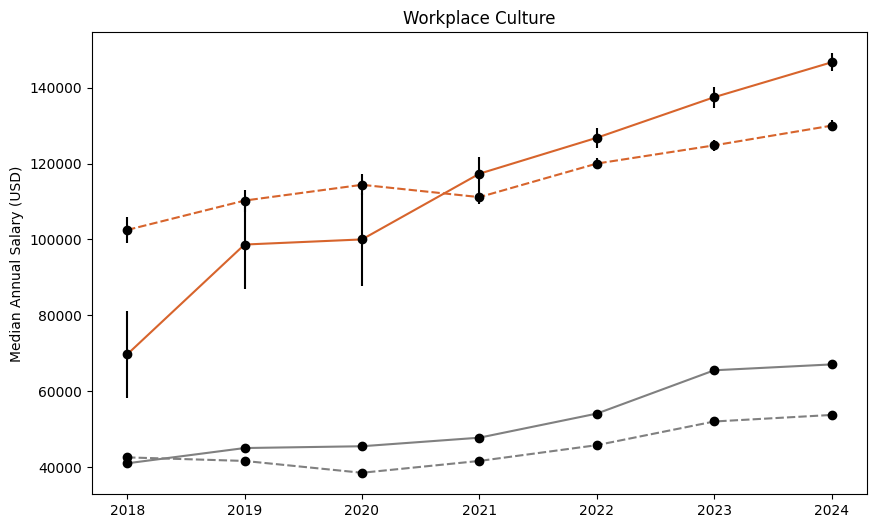

   YEAR AI ROLE wfh_wham   level_3        SALARY
0  2018   False      0.0    Median  40800.000000
1  2018   False      0.0  CI_Lower  32935.288661
2  2018   False      0.0  CI_Upper  48664.711339
3  2018   False      1.0    Median  57500.000000
4  2018   False      1.0  CI_Lower  34457.367317
    YEAR AI ROLE wfh_wham level_3    SALARY
0   2018   False      0.0  Median   40800.0
3   2018   False      1.0  Median   57500.0
6   2019   False      0.0  Median   40560.0
9   2019   False      1.0  Median   69705.0
12  2019    True      0.0  Median  104000.0
[<matplotlib.lines.Line2D object at 0x7f39b95a5310>, <matplotlib.lines.Line2D object at 0x7f39b95a5c70>, <matplotlib.lines.Line2D object at 0x7f39b95a5d00>, <matplotlib.lines.Line2D object at 0x7f39b95a7a10>, <matplotlib.lines.Line2D object at 0x7f39b95a4b30>, <matplotlib.lines.Line2D object at 0x7f39b95a6240>] ['AI ROLE', 'True', 'False', 'wfh_wham', 'True', 'False']


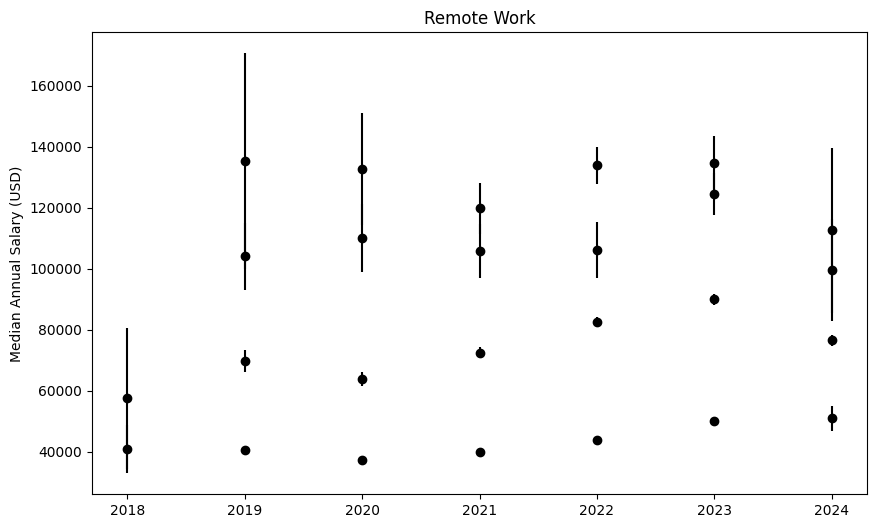

   YEAR AI ROLE REMOTE_KW   level_3        SALARY
0  2018   False     False    Median  41600.000000
1  2018   False     False  CI_Lower  41436.089113
2  2018   False     False  CI_Upper  41763.910887
3  2018   False      True    Median  64914.000000
4  2018   False      True  CI_Lower  63945.206372
    YEAR AI ROLE REMOTE_KW level_3    SALARY
0   2018   False     False  Median   41600.0
3   2018   False      True  Median   64914.0
6   2018    True     False  Median  100000.0
9   2018    True      True  Median  110000.0
12  2019   False     False  Median   40560.0
[<matplotlib.lines.Line2D object at 0x7f39bb09a750>, <matplotlib.lines.Line2D object at 0x7f39bb098830>, <matplotlib.lines.Line2D object at 0x7f39bb09b230>, <matplotlib.lines.Line2D object at 0x7f39bb099eb0>, <matplotlib.lines.Line2D object at 0x7f39bb099df0>, <matplotlib.lines.Line2D object at 0x7f39bacfcc20>] ['AI ROLE', 'True', 'False', 'REMOTE_KW', 'True', 'False']


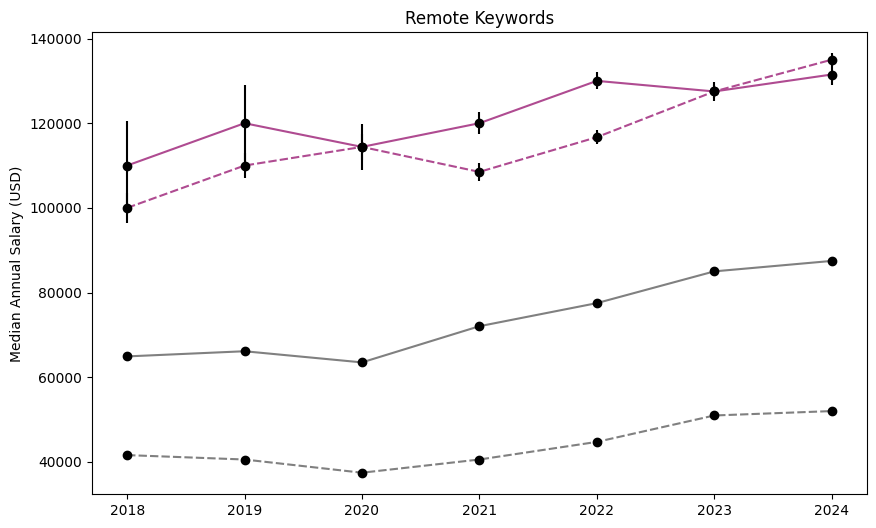

In [37]:
for benefit in benefits4:
    grouped_salary = usdf_salary.groupby(['YEAR', 'AI ROLE', benefit])['SALARY'].apply(
        lambda x: pd.Series(median_ci(x, confidence=0.95), index=['Median', 'CI_Lower', 'CI_Upper'])
    ).reset_index()
    # Convert the 'AI ROLE' and benefit to categorical if they are not already
    grouped_salary['AI ROLE'] = grouped_salary['AI ROLE'].astype(str)
    grouped_salary['SALARY'] = pd.to_numeric(grouped_salary['SALARY'], errors='coerce')
    grouped_salary['YEAR'] = grouped_salary['YEAR'].astype(int)

    grouped_salary[benefit] = grouped_salary[benefit].astype(str)
    print(grouped_salary.head())

    median_data = grouped_salary[grouped_salary['level_3'] == 'Median']
    print(median_data.head())
    palette = [benefit_colors[benefit], 'gray']

    # Plotting
    plt.figure(figsize=(10, 6))

    # Use Seaborn's lineplot to plot the median salaries
    sns.lineplot(
        data=median_data,
        x='YEAR',
        y='SALARY',
        hue='AI ROLE',
        style=benefit,
        markers=False,
        errorbar=None, 
        palette=palette, 
        style_order=['True', 'False'], 
        hue_order=['True', 'False']
    )

    # Adding error bars manually
    for skill in median_data['AI ROLE'].unique():
        for remote in grouped_salary[benefit].unique():
            subset = grouped_salary[(grouped_salary['AI ROLE'] == skill) & (grouped_salary[benefit] == remote)]
            medians = subset[subset['level_3'] == 'Median']
            ci_lowers = subset[subset['level_3'] == 'CI_Lower']['SALARY'].astype(float).values
            ci_uppers = subset[subset['level_3'] == 'CI_Upper']['SALARY'].astype(float).values
            yerr = np.array([medians['SALARY'].values - ci_lowers, ci_uppers - medians['SALARY'].values])

            plt.errorbar(
                x=medians['YEAR'],
                y=medians['SALARY'],
                yerr=yerr,
                fmt='o',
                color='black'
            )

    plt.xticks(median_data['YEAR'].unique())
    # Customize the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    print(handles, labels)
    # Extract the relevant handles and labels
    new_handles = handles
    new_labels = ['AI Role','Yes', 'No', f'{benefits_labels_map[benefit]}','Yes', 'No']
    if benefit == benefits4[0]:
        plt.legend(handles=new_handles, labels=new_labels, loc = 'upper left')
    else:
        plt.legend().remove()
    # set legend location
    # plt.legend(['','No AI Skills','AI Skills','','Not Remote','Remote'])
    # plt.legend(handles=handles[:4], labels=new_labels, title='Job Type and Remote Work')
    plt.xlabel(None)
    plt.ylabel('Median Annual Salary (USD)')
    plt.title(benefits_labels_map[benefit])
    # plt.title('Median Annual Salary by AI Skills and Remote Work with 95% Confidence Intervals')
    
    # if salary folder doesn't exist, create it
    if not os.path.exists('../figures/salary'):
        os.makedirs('../figures/salary')
    plt.savefig(f'../figures/salary/salary_by_{benefit}_color.png')

    plt.show()

In [12]:
usdf_salary['WLB'].dtype

dtype('bool')